In [1]:
import numpy as np
import polars as pl
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from pycaret.regression import *  # noqa: F403
from sklearn.model_selection import PredefinedSplit
import matplotlib.pyplot as plt
from path_config import PathConfig
from sklearn.neighbors import kneighbors_graph
paths = PathConfig()

In [2]:
def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371000  # Dünya yarıçapı (metre)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def create_folds(data, test_cluster, train_clusters, cluster_col="cluster"):
    used_clusters = set(train_clusters + [test_cluster])
    data = data[data[cluster_col].isin(used_clusters)].reset_index(drop=True)
    fold_indices = np.full(len(data), -1) 
    fold_indices[data[cluster_col] == test_cluster] = 0
    return data, PredefinedSplit(fold_indices)


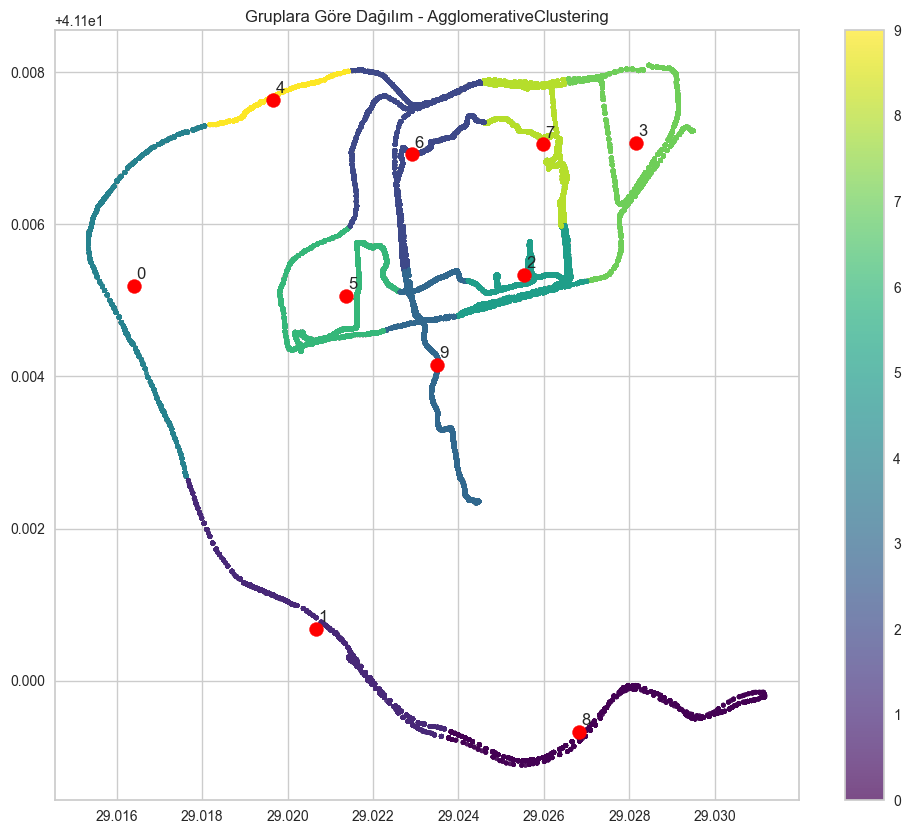

In [ ]:
data = pl.read_parquet(paths._processed_saha_olcum_dir / "merged_aggregated_data_dl.parquet")
unique_coords = data.unique(subset=["Longitude", "Latitude"]).select(["Longitude", "Latitude"])

x, y = unique_coords["Longitude"], unique_coords["Latitude"]
n = 10
X = np.concatenate((np.array(x).reshape(1,-1), np.array(y).reshape(1,-1)))
X = X.T

knn_graph = kneighbors_graph(X, 35, include_self=False, n_jobs=-1)
aggc = AgglomerativeClustering(n_clusters=n, linkage= "ward", connectivity = knn_graph).fit(X)

unique_coords = unique_coords.with_columns(
    pl.Series("cluster", aggc.labels_)
)

data = data.join(
    unique_coords.select(["Longitude", "Latitude", "cluster"]),
    on=["Longitude", "Latitude"],
    how="left"
)

cluster_centers_aggc = data.group_by("cluster").agg([
    pl.col("Longitude").mean(),
    pl.col("Latitude").mean()
])

cluster_centers_aggc_x = np.array(cluster_centers_aggc["Longitude"])
cluster_centers_aggc_y = np.array(cluster_centers_aggc["Latitude"])

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(1, 1, 1)

x, y = data["Longitude"], data["Latitude"]

sc = ax.scatter(
    x,
    y,
    c=data["cluster"],
    cmap="viridis",
    s=10,
    alpha=0.7
)

ax.scatter(
    cluster_centers_aggc_x,
    cluster_centers_aggc_y,
    s=100,
    c="red",
    
)

for i, (x_, y_) in enumerate(zip(cluster_centers_aggc_x, cluster_centers_aggc_y)):
    ax.annotate(str(i), (x_,y_), textcoords="offset points", xytext=(5, 5), ha='center')
    
ax.set_title("Gruplara Göre Dağılım - AgglomerativeClustering")

cbar = plt.colorbar(sc)

plt.show()
# clusterlar her seferinde farklı oluşuyor, bu sebeple clusterlı veriyi kaydediyorum. 
# data.write_parquet(paths._processed_saha_olcum_dir / "merged_aggregated_clustered_data_dl.parquet")

aggc_train_test = {
    1:[2,3,4,5,6,7,9],
    2:[0,1,4,5,6,8],
    3:[1,4,5,6,8,9,0],
    4:[1,2,3,5,7,8,9],
    5:[1,2,3,4,7,8,0],
    6:[1,2,3,8,0],
    7:[1,4,5,8,9,0],
    8:[2,3,4,5,6,7,9,0],
    9:[1,3,4,7,8,0],
    0:[2,3,5,6,7,8,9]
}

In [3]:
aggc_train_test = {
    1:[2,3,4,5,6,7,9],
    2:[0,1,4,5,6,8],
    3:[1,4,5,6,8,9,0],
    4:[1,2,3,5,7,8,9],
    5:[1,2,3,4,7,8,0],
    6:[1,2,3,8,0],
    7:[1,4,5,8,9,0],
    8:[2,3,4,5,6,7,9,0],
    9:[1,3,4,7,8,0],
    0:[2,3,5,6,7,8,9]
}

In [29]:
df = pd.read_parquet(paths._processed_saha_olcum_dir / "merged_aggregated_clustered_data_dl.parquet")
df

,Time,Longitude,Latitude,NR_UE_RSRP_0,NR_UE_RSRQ_0,NR_UE_SINR_0,NR_UE_Nbr_RSRP_0,NR_UE_Nbr_RSRP_1,NR_UE_Nbr_RSRP_2,NR_UE_Nbr_RSRP_3,...,MIMO,TOP_1_NBR_PCI_LONGITUDE_AVG,TOP_1_NBR_PCI_LATITUDE_AVG,TOP_2_NBR_PCI_LONGITUDE_AVG,TOP_2_NBR_PCI_LATITUDE_AVG,TOP_3_NBR_PCI_LONGITUDE_AVG,TOP_3_NBR_PCI_LATITUDE_AVG,TOP_4_NBR_PCI_LONGITUDE_AVG,TOP_4_NBR_PCI_LATITUDE_AVG,cluster
0,2025-03-14 12:14:33.444,29.02949,41.10723,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
1,2025-03-14 12:14:33.444,29.02949,41.10723,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
2,2025-03-14 12:14:33.444,29.02949,41.10723,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
3,2025-03-14 12:14:33.444,29.02949,41.10723,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
4,2025-03-14 12:14:34.000,29.02949,41.10723,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215894,2025-03-14 14:52:51.655,29.02441,41.10234,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
215895,2025-03-14 14:52:51.655,29.02441,41.10234,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
215896,2025-03-14 14:52:51.655,29.02441,41.10234,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
215897,2025-03-14 14:52:51.655,29.02441,41.10234,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3


In [30]:
object_cols = df.select_dtypes(include=['object']).columns.tolist()

df_fixed = df.copy()

for col in object_cols:
    # Unique değerleri al (null'ları çıkar)
    unique_vals = df[col].dropna().unique()
    
    # Tümü sayıya çevrilebilir mi kontrol et
    all_numeric = True
    for val in unique_vals:
        try:
            float(val)
        except (ValueError, TypeError):
            all_numeric = False
            break
    
    if all_numeric:
        # Tümü sayısal string ise numeric yap
        df_fixed[col] = pd.to_numeric(df_fixed[col], errors='coerce')

print(f"Numeric: {len(df_fixed.select_dtypes(include=['number']).columns)}")
print(f"Object: {len(df_fixed.select_dtypes(include=['object']).columns)}")

Numeric: 51
Object: 9


In [31]:
df_fixed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215899 entries, 0 to 215898
Data columns (total 61 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Time                         215899 non-null  datetime64[ms]
 1   Longitude                    215899 non-null  float64       
 2   Latitude                     215899 non-null  float64       
 3   NR_UE_RSRP_0                 5831 non-null    float64       
 4   NR_UE_RSRQ_0                 5831 non-null    float64       
 5   NR_UE_SINR_0                 5821 non-null    float64       
 6   NR_UE_Nbr_RSRP_0             4229 non-null    float64       
 7   NR_UE_Nbr_RSRP_1             1652 non-null    float64       
 8   NR_UE_Nbr_RSRP_2             278 non-null     float64       
 9   NR_UE_Nbr_RSRP_3             33 non-null      float64       
 10  NR_UE_Nbr_RSRP_4             2 non-null       float64       
 11  NR_UE_Nbr_RSRQ_0          

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007794 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4840
[LightGBM] [Info] Number of data points in the train set: 164388, number of used features: 54
[LightGBM] [Info] Start training from score 29.023295


,Description,Value
0,Session id,42
1,Target,Longitude
2,Target type,Regression
3,Original data shape,"(172383, 60)"
4,Transformed data shape,"(172383, 10)"
5,Transformed train set shape,"(164388, 10)"
6,Transformed test set shape,"(7995, 10)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0016,0.0000,0.0018,-0.0229,0.0001,0.0001
2,0.0010,0.0000,0.0015,-0.6025,0.0000,0.0000
Mean,0.0009,0.0000,0.0011,-0.2085,0.0000,0.0000
Std,0.0007,0.0000,0.0008,0.2788,0.0000,0.0000


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0016,0.0000,0.0018,-0.0180,0.0001,0.0001
2,0.0010,0.0000,0.0015,-0.6014,0.0000,0.0000
Mean,0.0009,0.0000,0.0011,-0.2065,0.0000,0.0000
Std,0.0007,0.0000,0.0008,0.2794,0.0000,0.0000


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.087736 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4880
[LightGBM] [Info] Number of data points in the train set: 109592, number of used features: 54
[LightGBM] [Info] Start training from score 29.023257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.086789 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4880
[LightGBM] [Info] Number of data points in the train set: 109592, number of used features: 54
[LightGBM] [Info] Start training from score 29.023257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.049215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4880
[LightGBM] [Info] Number of data points in the train se

...

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0006,0.0000,0.0007,-2.8388,0.0000,0.0000
2,0.0014,0.0000,0.0017,-0.1213,0.0000,0.0000
Mean,0.0006,0.0000,0.0008,-0.9867,0.0000,0.0000
Std,0.0006,0.0000,0.0007,1.3106,0.0000,0.0000


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0006,0.0000,0.0007,-2.7714,0.0000,0.0000
2,0.0014,0.0000,0.0017,-0.1205,0.0000,0.0000
Mean,0.0006,0.0000,0.0008,-0.9640,0.0000,0.0000
Std,0.0006,0.0000,0.0007,1.2790,0.0000,0.0000


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.151197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4880
[LightGBM] [Info] Number of data points in the train set: 109592, number of used features: 54
[LightGBM] [Info] Start training from score 41.105743
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.123719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4664
[LightGBM] [Info] Number of data points in the train set: 109592, number of used features: 52
[LightGBM] [Info] Start training from score 41.105738
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.076352 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total B

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,0.0048,0.0000,0.0049,-32.9653,0.0001,0.0001


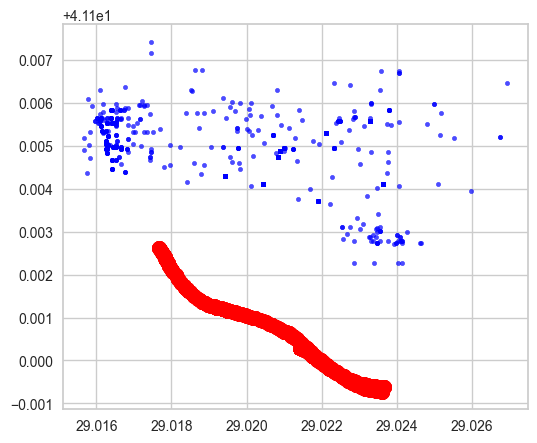

In [ ]:
predictions = pd.DataFrame()
haversine_distances = pd.DataFrame()

for i in aggc_train_test:
    train, test = df_fixed[[True if e in aggc_train_test[i] else False for e in df_fixed["cluster"]]], df_fixed[df_fixed["cluster"]==i]
    train, test = train.drop(columns=["cluster"]), test.drop(columns=["cluster"])

    temp_preds = pd.DataFrame()
    for target in ["Longitude","Latitude"]:
        ignore_feats = [
            'Time',
            "NAS_5GS_MM_MessageType",
            "NR_RRC_MsgType",
            "NR_UE_RRCReEst_EndResult",
            "NAS_5GS_SM_MessageType",
            "NR_UE_RACH_Procedure_Count",
            "NR_UE_Power_Tx_PRACH_0",
            "NR_UE_Nbr_RSRP_4",
            "NR_UE_Nbr_RSRQ_4"
        ]
        
        ordinal_feats = {
            "NR_UE_Modulation_Avg_DL_0": ["QPSK", "16QAM", "64QAM", "256QAM"],
            "NR_UE_RI_DL_0": ["Rank1", "Rank2", "Rank3", "Rank4"],
            "NR_UE_CCE_AggregationLev_0": ["LEVEL_1", "LEVEL_2", "LEVEL_4", "LEVEL_8", "LEVEL_16"],
            }
                
        if target == 'Longitude':
            ignore_feats.append('Latitude')
        else:
            ignore_feats.append('Longitude')

        clf_setup = setup( # noqa: F405
            data=train,
            test_data=test,
            target=target,
            ignore_features=ignore_feats,
            ordinal_features=ordinal_feats,
            imputation_type="iterative",
            iterative_imputation_iters = 5,
            numeric_iterative_imputer = "rf",
            categorical_iterative_imputer= "rf",
            #polynomial_features=True,
            fold = 3,
            feature_selection=True,
            verbose=True,
            session_id=42,
            log_data = True,
            )
        
        lr_model = create_model('xgboost') # noqa : F405
        lr_model = tune_model(lr_model, early_stopping=True, optimize="mse") # noqa : F405
        evaluate_model(lr_model) # noqa : F405
        
        temp_preds[f"predicted_{target}"] = predict_model(lr_model)["prediction_label"] # noqa : F405
        temp_preds[f"real_{target}"] = test[target]
        
    distances = haversine_np(
        temp_preds["predicted_Latitude"], 
        temp_preds["predicted_Longitude"], 
        temp_preds["real_Latitude"], 
        temp_preds["real_Longitude"]
        )
        
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(1, 1, 1)

    sc = ax.scatter(
        temp_preds["predicted_Longitude"],
        temp_preds["predicted_Latitude"],
        c="blue",
        s=10,
        alpha=0.7
    )

    ax.scatter(
        temp_preds["real_Longitude"],
        temp_preds["real_Latitude"],
        s=100,
        c="red",   
    )

    plt.show()
        
    distance_stats = pd.DataFrame({"Test_Cluster": [i], "Mean_Distance": [distances.mean()], "Max_Distance": [distances.max()]})
    haversine_distances = pd.concat([haversine_distances, distance_stats])


    pd.concat([predictions,temp_preds])


In [26]:
predictions

""


In [8]:
# Train/test uyumunu kontrol et
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train columns:", len(train.columns))
print("Test columns:", len(test.columns))

# Sütun farkı var mı?
train_cols = set(train.columns)
test_cols = set(test.columns)
print("Missing in test:", train_cols - test_cols)
print("Extra in test:", test_cols - train_cols)

# Ordinal features sorunlu mu?
missing_ordinal = [col for col in ordinal_feats.keys() if col not in train.columns]
print("Missing ordinal features:", missing_ordinal)

# Missing values kontrolü
print("Train missing values:", train.isnull().sum().sum())
print("Test missing values:", test.isnull().sum().sum())

Train shape: (158472, 60)
Test shape: (44958, 60)
Train columns: 60
Test columns: 60
Missing in test: set()
Extra in test: set()
Missing ordinal features: []
Train missing values: 7971174
Test missing values: 2224692


In [9]:
# %80'den fazla missing olan sütunları çıkar
missing_ratios = train.isnull().sum() / len(train)
usable_cols = missing_ratios[missing_ratios < 0.8].index.tolist()
print(f"Usable columns: {len(usable_cols)} / {len(train.columns)}")

# Bu sütunlarla iterative imputation dene
ignore_feats_clean = [col for col in ignore_feats if col in usable_cols]
ignore_feats_clean += [col for col in train.columns if col not in usable_cols and col != target]

Usable columns: 14 / 60


In [10]:
ignore_feats_clean

['Time',
 'Latitude',
 'NR_UE_RSRP_0',
 'NR_UE_RSRQ_0',
 'NR_UE_SINR_0',
 'NR_UE_Nbr_RSRP_0',
 'NR_UE_Nbr_RSRP_1',
 'NR_UE_Nbr_RSRP_2',
 'NR_UE_Nbr_RSRP_3',
 'NR_UE_Nbr_RSRP_4',
 'NR_UE_Nbr_RSRQ_0',
 'NR_UE_Nbr_RSRQ_1',
 'NR_UE_Nbr_RSRQ_2',
 'NR_UE_Nbr_RSRQ_3',
 'NR_UE_Nbr_RSRQ_4',
 'NR_UE_Timing_Advance',
 'NR_UE_Pathloss_DL_0',
 'NR_UE_Throughput_PDCP_DL',
 'App_Throughput_DL',
 'NR_UE_NACK_Rate_DL_0',
 'NR_UE_Ack_As_Nack_DL_0',
 'NR_UE_MCS_DL_0',
 'NR_UE_RB_Num_DL_0',
 'NR_UE_Modulation_Avg_DL_0',
 'NR_UE_RI_DL_0',
 'NR_UE_BLER_DL_0',
 'NR_UE_CCE_AggregationLev_0',
 'NR_UE_Power_Tx_PUSCH_0',
 'NR_UE_Power_Tx_PRACH_0',
 'NR_UE_NACK_Rate_UL_0',
 'NR_UE_RACH_Procedure_Count',
 'NR_UE_RRCReEst_EndResult',
 'NR_RRC_MsgType',
 'NAS_5GS_MM_MessageType',
 'NAS_5GS_SM_MessageType',
 'BS_LATITUDE',
 'BS_LONGITUDE',
 'BS_AZIMUTH',
 'BS_VERTICAL_BEAMWIDTH',
 'MIMO',
 'TOP_1_NBR_PCI_LONGITUDE_AVG',
 'TOP_1_NBR_PCI_LATITUDE_AVG',
 'TOP_2_NBR_PCI_LONGITUDE_AVG',
 'TOP_2_NBR_PCI_LATITUDE_AVG',
 'TO

In [88]:
empty_frame = pd.DataFrame()
empty_frame

""


In [93]:
distances

NameError: name 'distances' is not defined

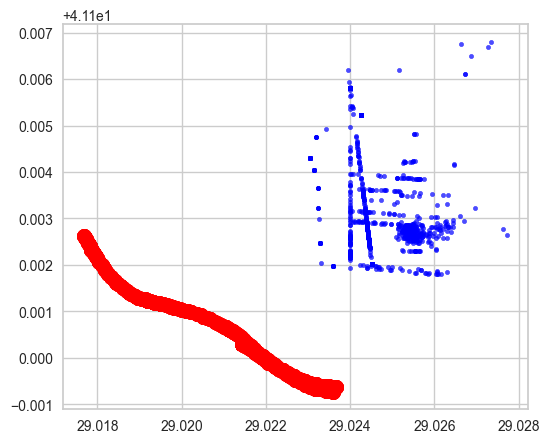

In [ ]:
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(1, 1, 1)

sc = ax.scatter(
    predictions["predicted_Longitude"],
    predictions["predicted_Latitude"],
    c="blue",
    s=10,
    alpha=0.7
)

ax.scatter(
    predictions["real_Longitude"],
    predictions["real_Latitude"],
    s=100,
    c="red",   
)

plt.show()

In [ ]:
distances = haversine_np(
    temp_preds["predicted_Latitude"], 
    temp_preds["predicted_Longitude"], 
    temp_preds["real_Latitude"], 
    temp_preds["real_Longitude"]
    )

In [94]:
predictions.mean()

predicted_Longitude    29.024084
real_Longitude         29.020658
predicted_Latitude     41.105512
real_Latitude          41.100687
dtype: float64

In [55]:
# Setup sonrası
clf_setup = setup(
    data=df_fixed,
    target=target,
    ignore_features=ignore_feats,
    log_data=True,
)

# Manuel olarak preprocessing'lenmiş veriyi al ve kaydet
X_train = get_config('X_train')
y_train = get_config('y_train')
X_test = get_config('X_test') 

# Manuel kaydetme
import pandas as pd

# Target bilgisini X'e ekle
train_data = X_train.copy()
train_data[target] = y_train

# Kaydet
train_data.to_csv(f'processed_train_{target.lower()}.csv', index=False)

if X_test is not None:
    test_data = X_test.copy()
    if get_config('y_test') is not None:
        test_data[target] = get_config('y_test')
    test_data.to_csv(f'processed_test_{target.lower()}.csv', index=False)

print(f"Manually saved: processed_train_{target.lower()}.csv")

,Description,Value
0,Session id,1706
1,Target,Longitude
2,Target type,Regression
3,Original data shape,"(215899, 61)"
4,Transformed data shape,"(215899, 82)"
5,Transformed train set shape,"(151129, 82)"
6,Transformed test set shape,"(64770, 82)"
7,Ignore features,4
8,Numeric features,48
9,Categorical features,8


Manually saved: processed_train_longitude.csv
